In [6]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-haar-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-haar-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_hc.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_hc.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_hc.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [13]:
file = npzread("/Users/uditvarma/Project_Data/z3-haar_2025-12-08_mean/Emean_L8,T80.0,dt1.0,p0.0_hc.npy")

80-element Vector{Float64}:
 -1.9984014443253304e-17
  1.262292432127888
  2.407181934950096
  3.2236410820985895
  3.642412329274977
  3.8065093335918836
  3.86620404124176
  3.884763052507316
  3.891973391725892
  3.892946487813995
  ⋮
  3.89536136478127
  3.8954078350385375
  3.894357654065216
  3.894193894130835
  3.8946663210726724
  3.894337053850629
  3.894829721196814
  3.8949522118984867
  3.8946461484406023

In [14]:
using Plots

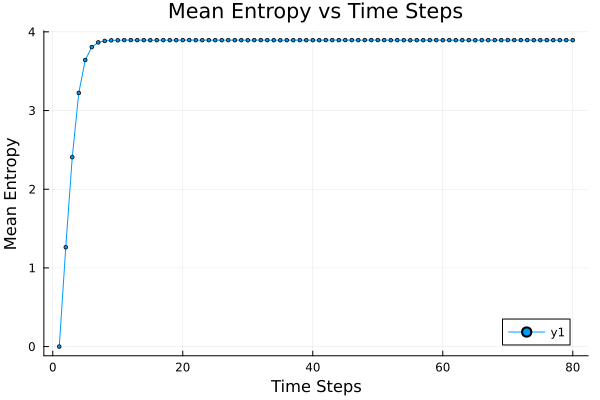

In [17]:
plot(file, xlabel="Time Steps", ylabel="Mean Entropy", title="Mean Entropy vs Time Steps", marker=:circle, markersize=2)

In [4]:
0.0:1.0:21

0.0:1.0:21.0

In [7]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in range(0.0, 1.0, length=21)
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved resu

In [8]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_hc.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


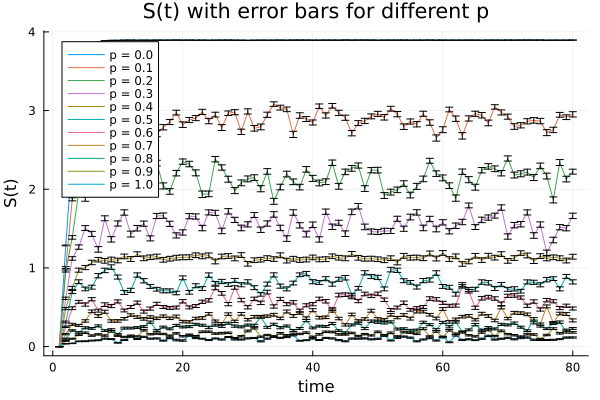

In [ ]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)


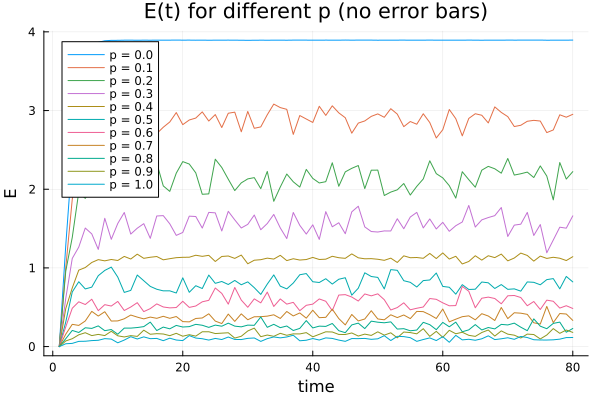

In [26]:
using NPZ
using Glob
using Printf
using Dates
using Plots

function plot_all_p_noerr(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Locate all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()

    # Read mean files
    for mf in mean_files
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))
    end

    # Sort by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot all curves (no error bars)
    plt = plot(title="E(t) for different p (no error bars)",
               xlabel="time", ylabel="E")

    for i in 1:length(p_values)
        plot!(t, mean_list[i], label=@sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end

# Run it
plot_all_p_noerr(8, 80.0, 1.0)


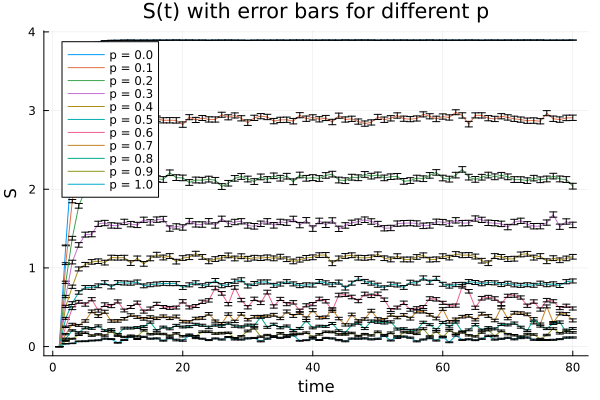

In [32]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)

plot_selected_p (generic function with 1 method)

In [36]:
using NPZ
using Glob
using Printf
using Plots

function plot_selected_p(L, T, dt, p_list_to_plot)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    all_mean_files = Glob.glob(pattern, folder)

    if isempty(all_mean_files)
        println("No files found in $folder")
        return
    end

    # Storage
    selected_p = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    for mf in all_mean_files
        fname = basename(mf)

        # Extract p value
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        # Skip p values NOT requested
        if !(p in p_list_to_plot)
            continue
        end

        push!(selected_p, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    if isempty(selected_p)
        println("No requested p values found.")
        return
    end

    # Sort by p
    perm = sortperm(selected_p)
    selected_p = selected_p[perm]
    mean_list  = mean_list[perm]
    var_list   = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot
    plt = plot(title="S(t) vs t",
               xlabel="Time", ylabel="S")

    for i in 1:length(selected_p)
        errors = sqrt.(var_list[i]) ./ sqrt(1000)
        plot!(t, mean_list[i], yerr=errors,
              label=@sprintf("p = %.2f", selected_p[i]))
    end

    display(plt)
end

plot_selected_p (generic function with 1 method)

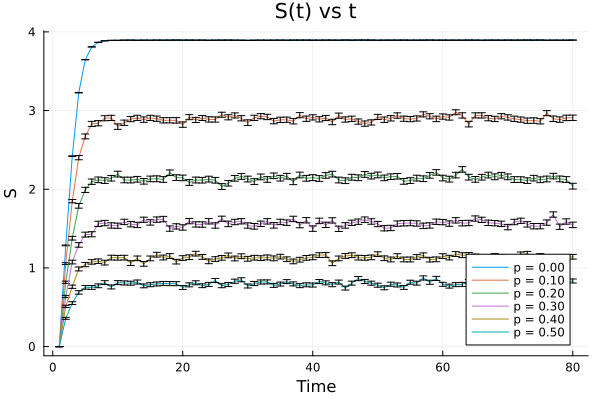

In [37]:
plot_selected_p(8, 80.0, 1.0, [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

In [2]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     5000
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    4980
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [1]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     4990
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    5000
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [11]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [40]:
using NPZ
using Glob
using Printf
using Plots

function plot_final_variance_vs_p_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    plt = plot(
        xlabel = "p",
        ylabel = "δS(t)",
        title  = "Steady-state variance vs p",
        legend = :topright,
        marker = :circle
    )

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Evar_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        var_files = Glob.glob(pattern, folder)

        if isempty(var_files)
            @warn "No variance files found for L=$L"
            continue
        end

        p_values = Float64[]
        final_vars = Float64[]

        for vf in var_files
            fname = basename(vf)

            # extract p from filename
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            var_data = npzread(vf)
            final_var = var_data[end]   # FINAL TIME VALUE

            push!(p_values, p)
            push!(final_vars, final_var)
        end

        # sort by p
        perm = sortperm(p_values)
        p_values   = p_values[perm]
        final_vars = final_vars[perm]

        plot!(
            p_values,
            final_vars,
            label = @sprintf("L = %d", L)
        )
    end

    # -----------------------
    # SAVE AS SVG
    # -----------------------
    out_svg = joinpath(mean_root, "final_variance_vs_p.svg")
    savefig(plt, out_svg)

    println("Saved → $out_svg")
end

# ----------------------
# CALL
# ----------------------
plot_final_variance_vs_p_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/final_variance_vs_p.svg


In [12]:
npzread("/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/Emean_L8,T80.0,dt1.0,p1.0_hc.npy")

80-element Vector{Float64}:
 3.6415315207705074e-17
 0.040900373511640734
 0.05510347731805159
 0.0734323807387099
 0.084224322229018
 0.05406211386132771
 0.09283863172387151
 0.08826277903976977
 0.08548485956382391
 0.088564541275996
 0.07828718828234373
 0.0949872042023508
 0.09294522387652444
 ⋮
 0.08631777343676288
 0.09954668633263328
 0.09065140425807809
 0.10274122726200176
 0.10282802018011926
 0.09662265428260665
 0.0958155033064394
 0.10124594595652163
 0.09647232569666762
 0.09183558382496805
 0.09457815606317478
 0.10692030858965909

### Shannon entropy data

In [28]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-shannon-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [29]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000

In [31]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [42]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-shannon-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = false
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [35]:
using NPZ
using Glob
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# -------------------------------------------------
# Find all L folders
# -------------------------------------------------
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Detect p values for this L
    # -------------------------------------------------
    mean_files = Glob.glob("Emean_L*,p*_se.npy", L_folder)

    p_vals = Float64[]
    for f in mean_files
        m = match(r"p([0-9]+\.[0-9]+)", basename(f))
        m !== nothing && push!(p_vals, parse(Float64, m.captures[1]))
    end
    p_vals = sort(unique(p_vals))

    np = length(p_vals)
    @assert np > 0 "No p values found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, np, 3)

    # -------------------------------------------------
    # Load final values
    # -------------------------------------------------
    for (ip, p) in enumerate(p_vals)

        mean_file = joinpath(
            L_folder,
            @sprintf("Emean_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )
        var_file = joinpath(
            L_folder,
            @sprintf("Evar_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )

        if !isfile(mean_file) || !isfile(var_file)
            @warn "Missing data for L=$L p=$p"
            data[ip, :] .= NaN
            continue
        end

        data[ip, 1] = p
        data[ip, 2] = npzread(mean_file)[end]  # final mean
        data[ip, 3] = npzread(var_file)[end]   # final variance
    end

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end


Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


┌ Warning: Missing data for L=10 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.6
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.7
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.8
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.9
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=1.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing d

In [36]:
using NPZ
using Glob
using Printf

base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Find all L folders
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Find all mean files for this L
    # -------------------------------------------------
    mean_files = sort(Glob.glob("Emean_L*,p*_se.npy", L_folder))
    nfiles = length(mean_files)

    @assert nfiles > 0 "No mean files found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, nfiles, 3)

    # -------------------------------------------------
    # Loop over files
    # -------------------------------------------------
    for (i, mf) in enumerate(mean_files)
        fname = basename(mf)

        # Extract p robustly
        mp = match(r"p([0-9]*\.?[0-9]+)", fname)
        mp === nothing && error("Could not parse p from $fname")
        p = parse(Float64, mp.captures[1])

        # Corresponding variance file
        vf = replace(mf, "Emean" => "Evar")
        @assert isfile(vf) "Missing variance file for $fname"

        # Load final values
        data[i, 1] = p
        data[i, 2] = npzread(mf)[end]
        data[i, 3] = npzread(vf)[end]
    end

    # -------------------------------------------------
    # Sort by p
    # -------------------------------------------------
    perm = sortperm(data[:, 1])
    data = data[perm, :]

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end



Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


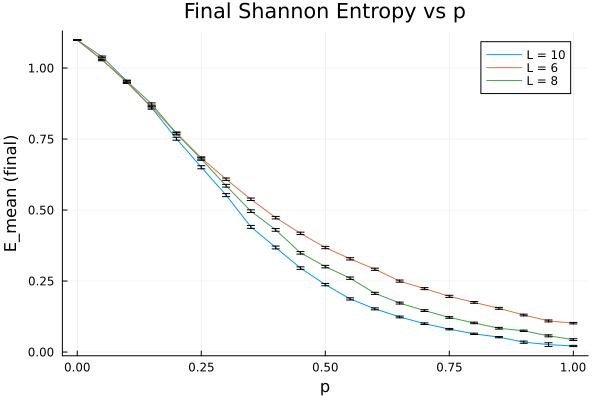

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [37]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots (CHANGE if needed)
Nshots = 5000

# -------------------------------------------------
# Find all per-L summary files
# -------------------------------------------------
summary_files = sort(Glob.glob("E_final_L*.npy", mean_root))
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "E_mean (final)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L with error bars
# -------------------------------------------------
for f in summary_files
    fname = basename(f)

    # Extract L
    m = match(r"L(\d+)", fname)
    m === nothing && continue
    L = parse(Int, m.captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    # Error bars
    err = sqrt.(var ./ Nshots)   # ← remove "/ Nshots" if undesired

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


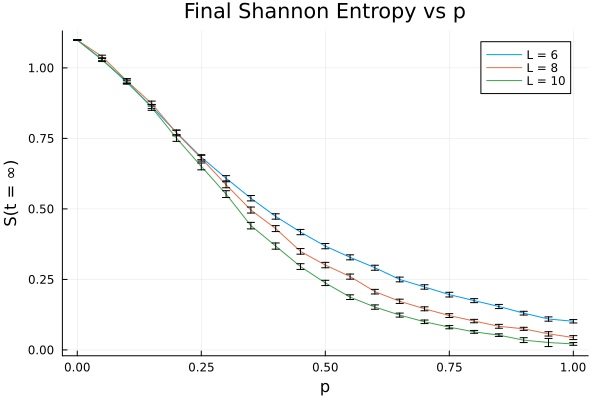

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [44]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


In [ ]:
xlims!(plt, 0.3, 0.7)


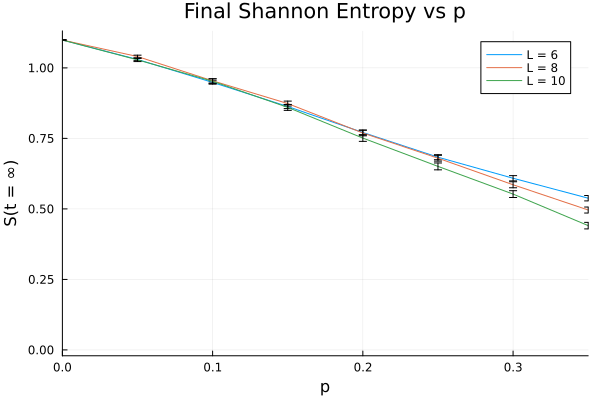

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_zoomed.svg


In [49]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
xlims!(plt, 0.0, 0.35)

out_svg = joinpath(mean_root, "Emean_vs_p_all_L_zoomed.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


### Optimized code

In [54]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_hc"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [52]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_se"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [60]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-opt-data-2Jan2026")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-opt-data-2Jan2026-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [61]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [8, 12]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 4990 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4990 matching shots.
Saved results to /Users/dira

In [62]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "Lq$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [63]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-opt-data-2Jan2026-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "Lq$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("Sq_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([8, 12], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq8/Sq_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq12/Sq_vs_t_L12.svg
